# **LIMPIEZA DE DATOS CON PYTHON**
---

Importamos los paquetes que vamos a usar

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import  SimpleImputer

Cargamos los datos

In [164]:
from pathlib import Path
import pandas as pd

# Cargar específicamente train03.csv
csv_path = Path("clases_actividad12") / "train03.csv"
if not csv_path.exists():
    csv_path = Path("train03.csv")

# train03.csv trae el nombre con una coma sin comillas ("Braund, Mr. ..."),
# por eso se parte en 2 columnas y luego falla astype(int) en Pclass.
cols_raw = [
    "PassengerId", "Survived", "Pclass", "Name_1", "Name_2", "Sex",
    "Age", "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"
]

raw = pd.read_csv(csv_path, sep=",", engine="python", header=0, names=cols_raw)

# Reconstruir nombre completo y dejar esquema estándar Titanic
raw["Name"] = raw["Name_1"].astype(str).str.strip() + ", " + raw["Name_2"].astype(str).str.strip()
data = raw.drop(columns=["Name_1", "Name_2"])

# Asegurar tipos numéricos donde corresponde
for col in ["PassengerId", "Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Reordenar columnas para mantener compatibilidad con el resto del notebook
data = data[[
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"
]]

data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1.0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0.0,A/5 21171,7.250,NaN,S
1,2.0,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0.0,PC 17599,712.833,C85,C
2,3.0,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0.0,STON/O2. 3101282,7.925,NaN,S
3,4.0,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0.0,113803,53.100,C123,S
4,5.0,0,3,"Allen, Mr. William Henry",male,35.0,0,0.0,373450,8.050,NaN,S


Recordemos algunos métodos útiles de los dataframe de pandas

In [152]:
data.head() # Mostrar las primeras filas del DataFrame

,Idpasajero,Sobrevive,Clase,Nombre,Sex,Edad,SibSp,Parch,Ticket,Fare,Cabina,Embarque
1,0,3,Braund,Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.25,NaN,S
2,1,1,Cumings,Mrs. John Bradley (Florence Briggs Thayer),female,38.0,1,0,PC 17599,712.833,C85,C
3,1,3,Heikkinen,Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
4,1,1,Futrelle,Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1,C123,S
5,0,3,Allen,Mr. William Henry,male,35.0,0,0,373450,8.05,NaN,S


Para ver una informacion general sobre los atributos del dataframe

In [ ]:
data.info(memory_usage="deep") # Mostrar información detallada del DataFrame, incluyendo el uso de memoria

- PassengerId: Identificador único de cada pasajero. No aporta información del fenómeno, solo identifica filas.
- Survived: Variable objetivo.
0 = no sobrevivió, 1 = sobrevivió.
- Pclass: Clase del boleto.
1 = primera clase, 2 = segunda, 3 = tercera.
- Name: Nombre completo del pasajero.
- Sex: Sexo del pasajero (male/female).
- Age: Edad en años. Puede tener valores faltantes.
- SibSp: Número de hermanos/esposo-esposa a bordo con el pasajero.
- Parch: Número de padres/hijos a bordo con el pasajero.
- Ticket: Número de ticket/pasaje.
- Fare: Tarifa pagada por el ticket.
- Cabin: Número de cabina. Tiene muchos nulos en este dataset.
- Embarked: Puerto de embarque. C = Cherbourg, Q = Queenstown, S = Southampton.

Para obtener una descrpcion estadistica de las columnas numericas

In [153]:
data.describe() # Estadísticas descriptivas para columnas numéricas

,Idpasajero,Sobrevive,Edad,SibSp
count,891.000000,891.000000,732.000000,891.000000
mean,0.383838,2.308642,27.867719,0.521886
std,0.486592,0.836071,15.968490,1.080118
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,19.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000
75%,1.000000,3.000000,37.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000


Para obtener una descripcion de las categoricas

In [154]:
# Estadísticas descriptivas para columnas categóricas sin usar include=['O']
cat_cols = data.select_dtypes(include=["object", "string", "category"]).columns

if len(cat_cols) > 0:
    data[cat_cols].describe().T
else:
    print("No hay columnas categóricas para describir.")

Para ver el tamaño del dataset

In [155]:
data.shape # Mostrar el número de filas y columnas del DataFrame

(891, 12)

Para cambiar el tipo de dato de una columna

In [162]:
data['Clase']=data['Clase'].astype(str) # Convertir 'Pclass' a tipo string para tratarlo como categórico
data.info()

<class 'pandas.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Idpasajero  891 non-null    int64  
 1   Sobrevive   891 non-null    int64  
 2   Clase       891 non-null    str    
 3   Nombre      891 non-null    str    
 4   Sex         873 non-null    str    
 5   Edad        732 non-null    float64
 6   SibSp       891 non-null    int64  
 7   Parch       891 non-null    str    
 8   Ticket      891 non-null    str    
 9   Fare        846 non-null    str    
 10  Cabina      249 non-null    str    
 11  Embarque    836 non-null    str    
dtypes: float64(1), int64(3), str(8)
memory usage: 90.5+ KB


In [ ]:
data['Clase']=data['Clase'].astype(int) # Convertir 'Pclass' de nuevo a tipo numérico para análisis estadístico

## **COMPROBACION DE OUTLIERS**

De forma visual

In [ ]:
num_cols=data.select_dtypes(include='number').columns # Seleccionar solo las columnas numéricas

for col in num_cols:
  plt.figure(figsize=(17,1)) # Ajustar el tamaño de la figura para que los boxplots sean más delgados
  sns.boxplot(data=data[num_cols], x=col) # Crear un boxplot para cada columna numérica
  
  # Crear un boxplot para cada columna objectiva (categórica) usando sns.countplot
# cat_cols=data.select_dtypes(include='object').columns # Seleccionar solo las columnas categ
# for cat_col in cat_cols:
#     plt.figure(figsize=(17,1)) # Ajustar el tamaño de la figura para que los countplots sean más delgados
#     sns.countplot(data=data, x=cat_col) # Crear un countplot para cada columna categórica   
# data.isna().sum() # Contar el número de valores faltantes en cada columna
# data.drop('Age',axis=1,inplace=True)
# data.drop('Cabin',axis=1,inplace=True)
# data.isna().sum() # Contar el número de valores faltantes en cada columna



Numericamente

In [ ]:
#Nº de Outliers usando rango IQR
outliers={}

for col in num_cols:
  Q1 = np.percentile(data[col], 25)
  Q3 = np.percentile(data[col], 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers[col]= (data[col] > upper_bound).sum() + (data[col]< lower_bound).sum()

print(outliers)

In [ ]:
#Nº de Outliers usando 3 std
outliers={}
for col in num_cols:
  mean=data[col].mean() # Calcular la media de la columna
  std=data[col].std()

  outliers[col] = (data[col] > (mean + 3 *std)).sum() + (data[col] < (mean - 3 *std)).sum() 
  # Contar los valores que están por encima de la media + 3*std o por debajo de la media - 3*std

print(outliers)

In [ ]:
sns.histplot(data['Fare']) # Histograma de la columna 'Fare'

Veamos ahora los diferentes metodos de trabajar con nulos

In [166]:
data.isna().sum() # Contar el número de valores faltantes en cada columna

PassengerId      1
Survived         0
Pclass           0
Name             0
Sex             18
Age            159
SibSp            0
Parch           15
Ticket           0
Fare            76
Cabin          642
Embarked        55
dtype: int64

Eliminando los nulos

In [167]:
data.drop('Age',axis=1,inplace=True) # Eliminar la columna 'Age' debido a su alto número de valores faltantes

In [168]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  890 non-null    float64
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          873 non-null    str    
 5   SibSp        891 non-null    int64  
 6   Parch        876 non-null    float64
 7   Ticket       891 non-null    str    
 8   Fare         815 non-null    float64
 9   Cabin        249 non-null    str    
 10  Embarked     836 non-null    str    
dtypes: float64(3), int64(3), str(5)
memory usage: 76.7 KB


Imputando valores

In [169]:
sns.histplot(data['Age']) # Histograma de la columna 'Age' después de eliminarla (debería mostrar un error o no mostrar nada)

KeyError: 'Age'

In [ ]:
impute=SimpleImputer(strategy='median')

print('Mediana inicial: ', data['Age'].median())

salida=impute.fit_transform(data[['Age']])

salida=pd.DataFrame(salida)

print('\nNulos en los nuevos datos: ',salida.isna().sum())
print('\nMediana nuevos datos: ',salida.median())


Usando una constante(Por ejemplo para columnas categoricas)

In [170]:
data.Embarked.value_counts() # Contar el número de ocurrencias de cada valor en la columna 'Embarked'

Embarked
S    614
C    159
Q     63
Name: count, dtype: int64

In [171]:
impute=SimpleImputer(strategy='constant',fill_value='S')

print('Recuento inicial: ', data['Embarked'].value_counts())

salida=impute.fit_transform(data[['Embarked']])

salida=pd.DataFrame(salida)

print('\nNulos en los nuevos datos: ',salida.isna().sum())
print('\Recuento nuevos datos: ',salida.value_counts())

Recuento inicial:  Embarked
S    614
C    159
Q     63
Name: count, dtype: int64

Nulos en los nuevos datos:  0    0
dtype: int64
\Recuento nuevos datos:  0
S    669
C    159
Q     63
Name: count, dtype: int64


<>:10: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
<>:10: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
C:\Users\ocog1\AppData\Local\Temp\ipykernel_29036\2420672655.py:10: SyntaxWarning: "\R" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\R"? A raw string is also an option.
  print('\Recuento nuevos datos: ',salida.value_counts())


# **PARTE 2 LIMPIEZA**
---

Comprender las variable

In [172]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  890 non-null    float64
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          873 non-null    str    
 5   SibSp        891 non-null    int64  
 6   Parch        876 non-null    float64
 7   Ticket       891 non-null    str    
 8   Fare         815 non-null    float64
 9   Cabin        249 non-null    str    
 10  Embarked     836 non-null    str    
dtypes: float64(3), int64(3), str(5)
memory usage: 76.7 KB


Descripción de cada columna:
- Survived : Sobrevivio o no? 0-1
- Pclass : En que clase viajaba
- Name: Nombre del pasajero
- Sex: Es hombre o mujer?
- Age: Edad del pasajero
- SibSp: Número de hermanos/cónyuges a bordo del Titanic
- Parch: Número de padres/hijos a bordo del Titanic
- Ticket: Número de boleto
- Fare: Tarifa del pasajero
- Embarked: Puerto de embarque

### Varianza en los datos

In [ ]:
data.var() # Calcular la varianza de las columnas numéricas del DataFrame

In [ ]:
cat_cols=data.select_dtypes(include='O').columns # Seleccionar solo las columnas de tipo object (categóricas)

for c in cat_cols:
  print('\nColumna :',c)
  print(data[c].value_counts()) # Contar el número de ocurrencias de cada valor en la columna categórica

### Matriz de correlación

In [ ]:
num_cols=data.select_dtypes(include='number').columns

matriz=data[num_cols].corr()

sns.heatmap(matriz,annot=True)

Vemos que si incluimos la variable objetivo podemos ver como de relacionadas estan el resto de variables con esta.

### Exploracion visual


Visualizaciones para la columna:  PassengerId


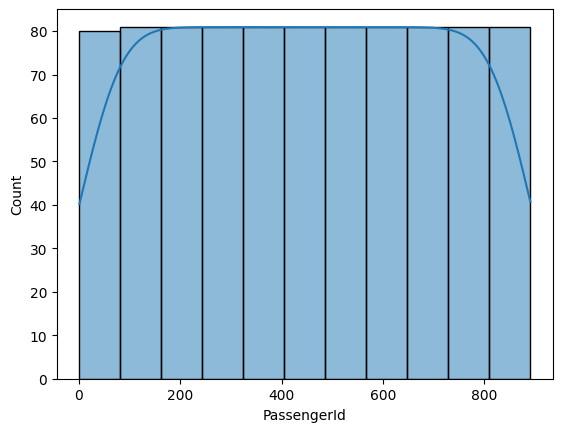

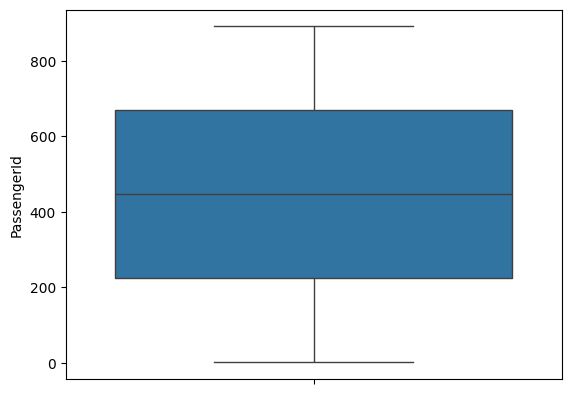


Visualizaciones para la columna:  Survived


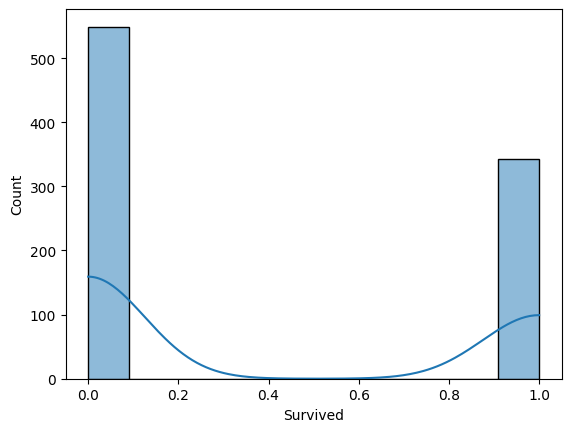

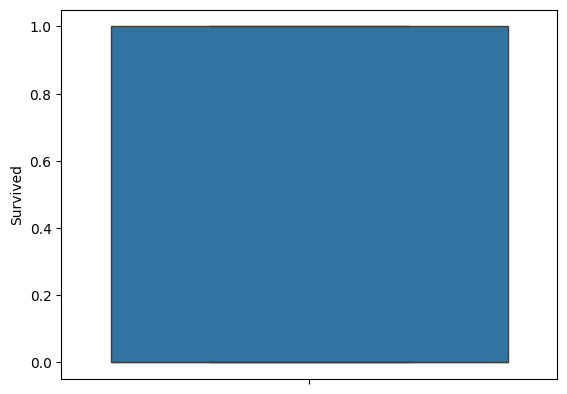


Visualizaciones para la columna:  Pclass


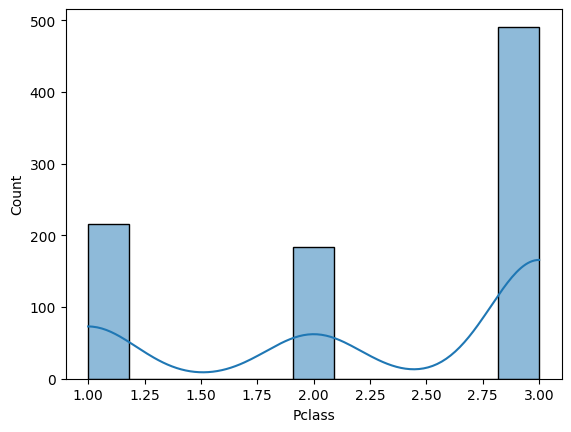

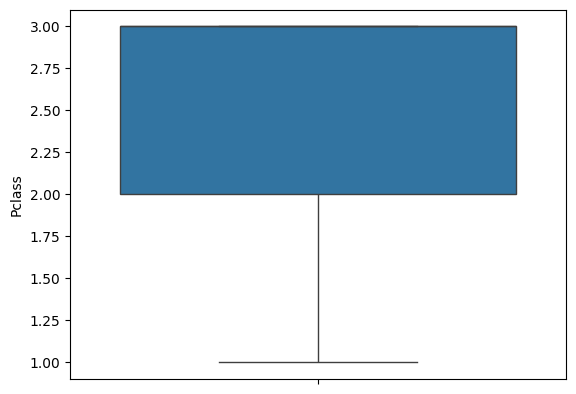


Visualizaciones para la columna:  SibSp


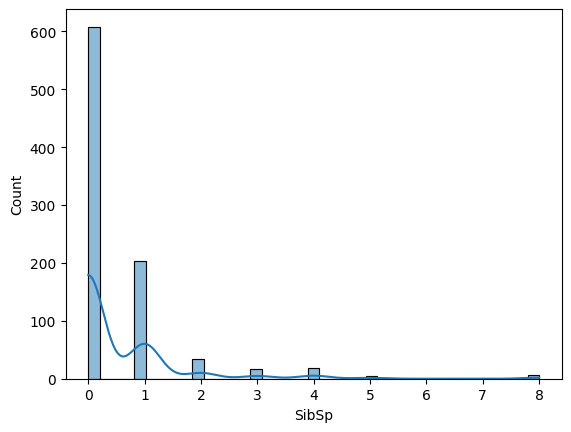

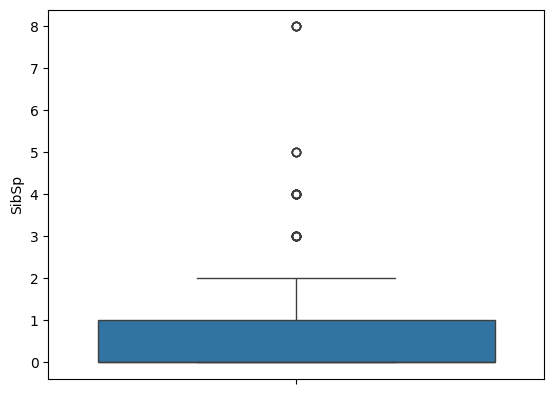


Visualizaciones para la columna:  Parch


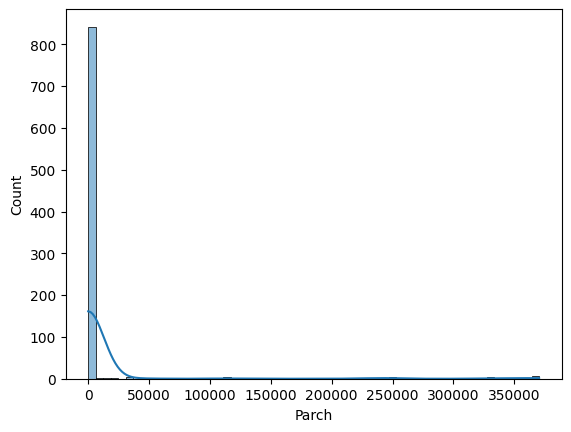

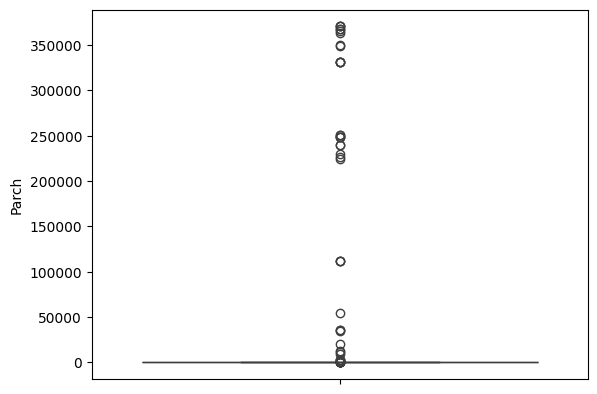


Visualizaciones para la columna:  Fare


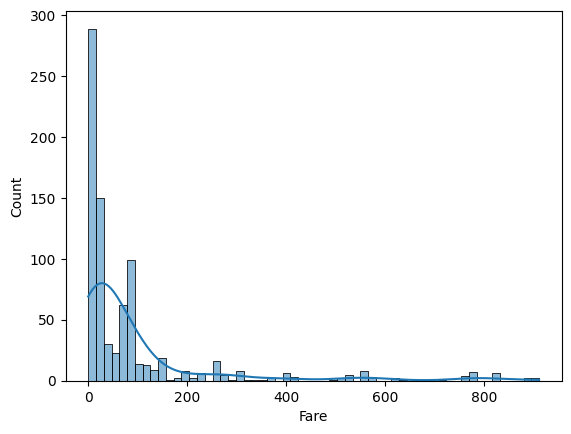

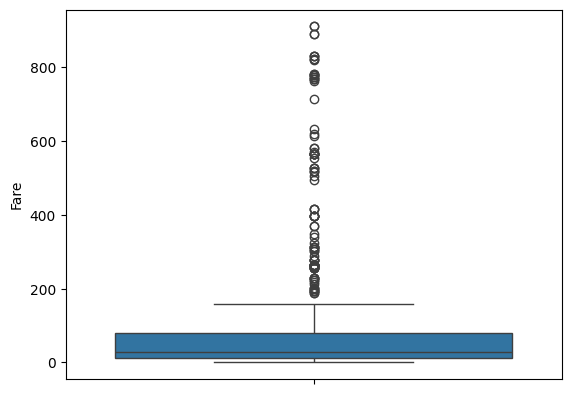

In [173]:
#Columnas numéricas
for col in num_cols:
  print('\nVisualizaciones para la columna: ',col)
  sns.histplot(data[col],kde=True)
  plt.show()
  sns.boxplot(data[col])
  plt.show()

In [174]:
#Columnas categóricas
for c in cat_cols:
  sns.barplot(data[c])
  plt.show()

KeyError: 'Clase'

### DESBALANCEO EN LA VARIABLE OBJETIVO

In [ ]:
data.Survived.value_counts() / len(data) # Calcular la proporción de cada clase en la columna 'Survived'

Survived
0    0.616162
1    0.383838
Name: count, dtype: float64

<Axes: xlabel='Survived', ylabel='count'>

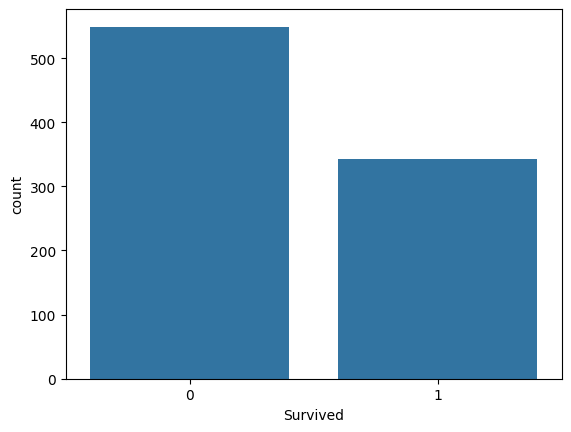

In [176]:
sns.barplot(data['Survived'].value_counts())

Vemos que exite desbalanceo aunque no sea muy severo, pero debemos corregirlo para mejorar la calidad de los datos.

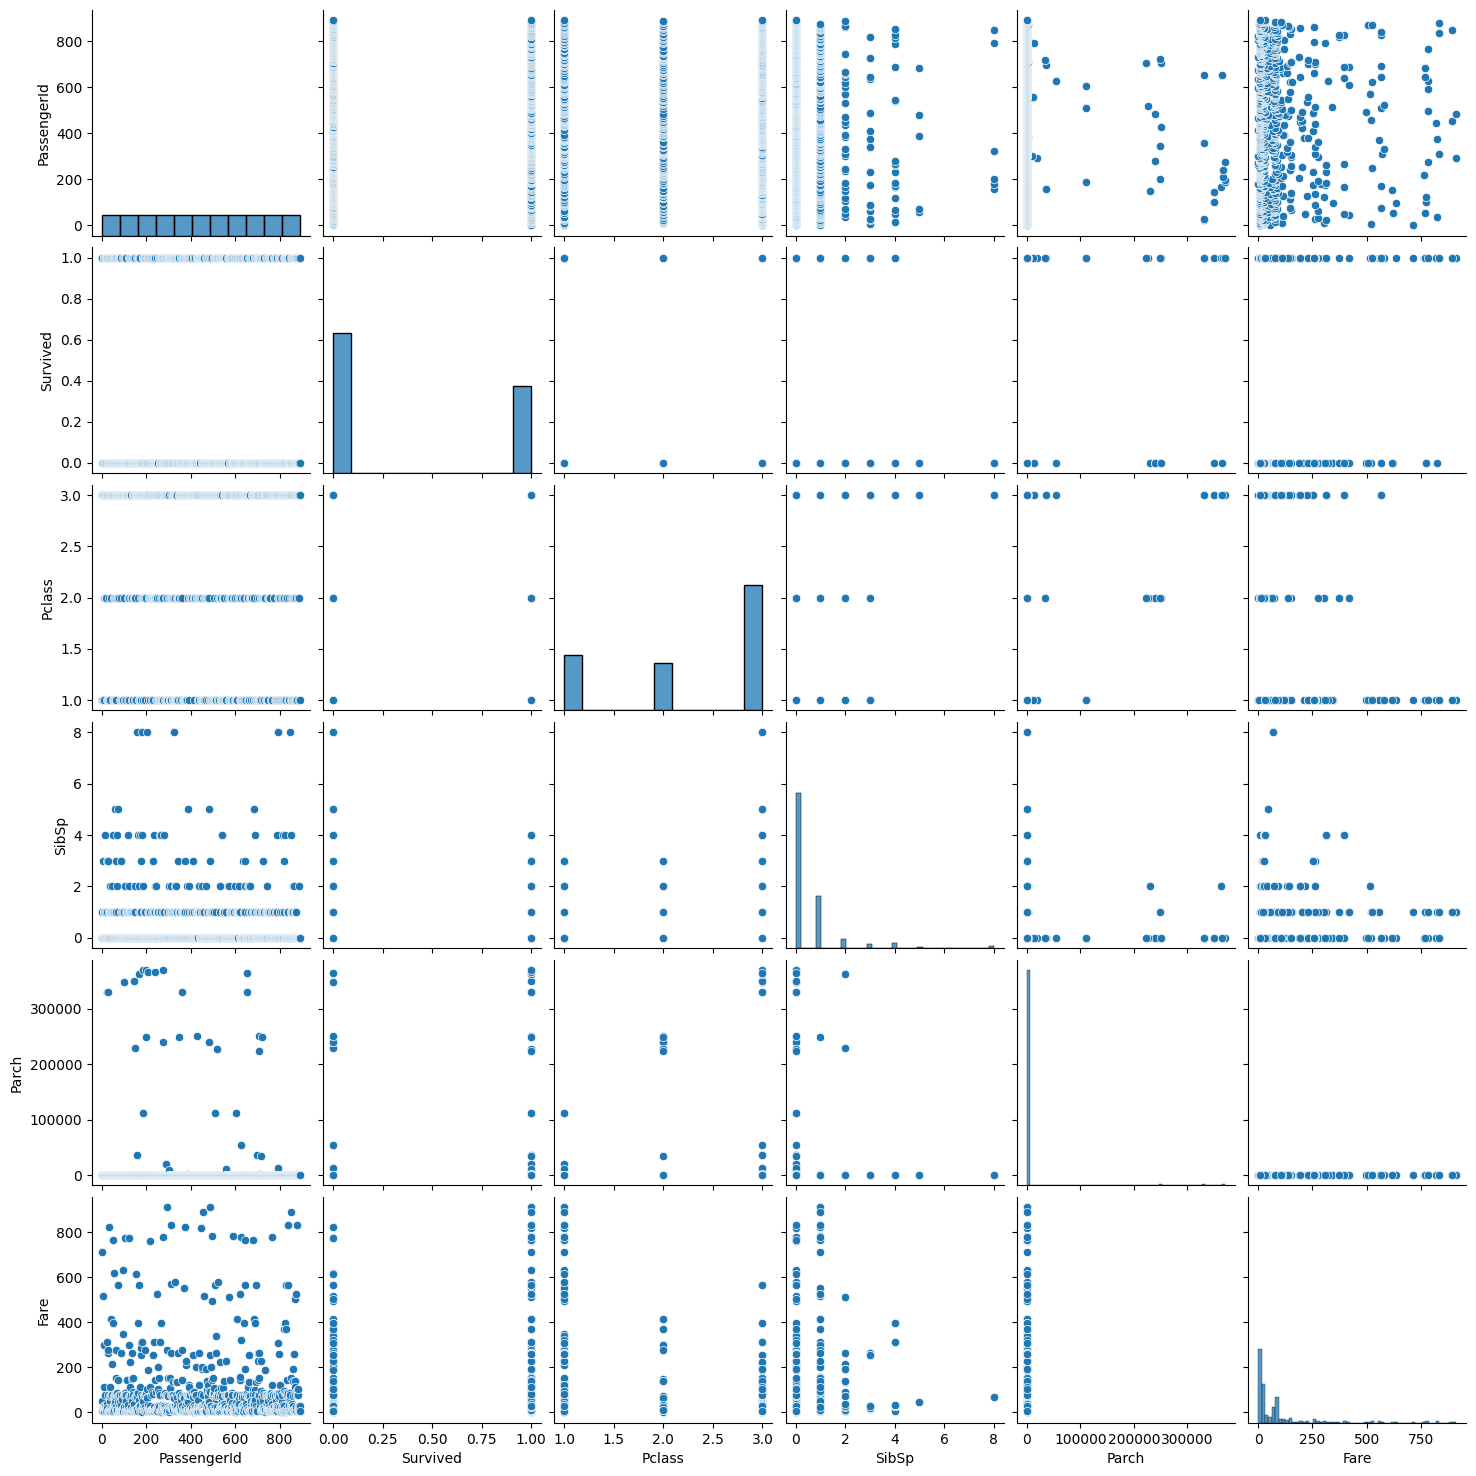

In [ ]:
sns.pairplot(data) # Crear un pairplot para visualizar las relaciones entre todas las columnas numéricas del DataFrame
# el analisis de los datos se hace con el pairplot, ya que se pueden observar las relaciones entre las columnas 
# numéricas y la distribución de cada una de ellas.

### Gráfico demostrativo: Pclass vs Survived

Este gráfico muestra cuántos pasajeros sobrevivieron y cuántos no, agrupados por clase de viaje.

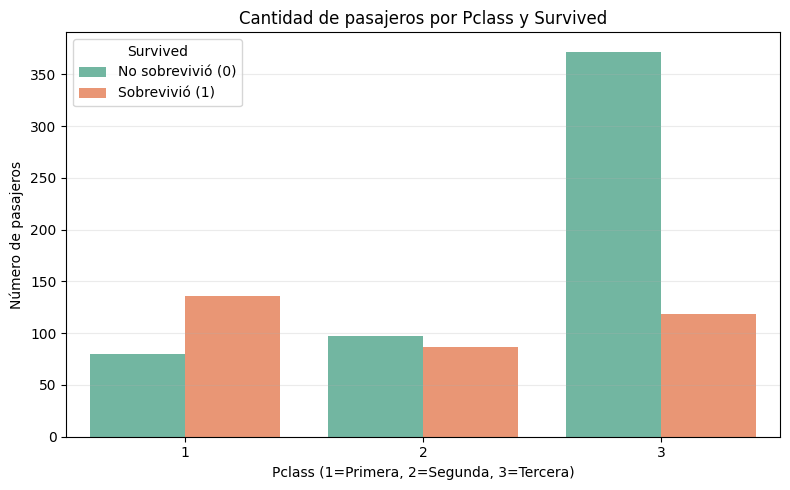

In [183]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Conteo de sobrevivientes y no sobrevivientes por clase
sns.countplot(
    data=data,
    x="Pclass",
    hue="Survived",
    palette="Set2"
)

plt.title("Cantidad de pasajeros por Pclass y Survived")
plt.xlabel("Pclass (1=Primera, 2=Segunda, 3=Tercera)")
plt.ylabel("Número de pasajeros")
plt.legend(title="Survived", labels=["No sobrevivió (0)", "Sobrevivió (1)"])
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### Versión ejecutiva: tasa de supervivencia por Pclass

Este gráfico muestra la proporción de supervivencia media por clase, con el intervalo de confianza al 95%.

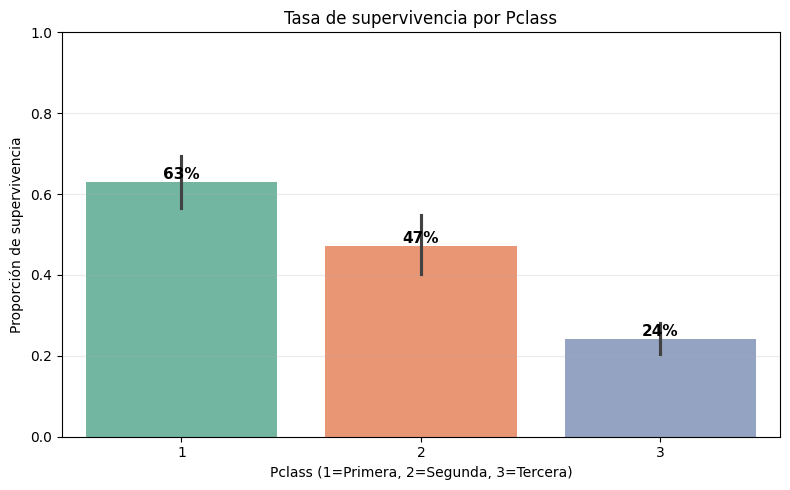

In [184]:

plt.figure(figsize=(8, 5))

# Tasa de supervivencia media por clase con intervalo de confianza
sns.barplot(
    data=data,
    x="Pclass",
    y="Survived",
    hue="Pclass",
    palette="Set2",
    errorbar="ci",
    legend=False
)

# Anotar el % encima de cada barra
for patch, pclass in zip(plt.gca().patches, sorted(data["Pclass"].dropna().unique())):
    tasa = data[data["Pclass"] == pclass]["Survived"].mean()
    plt.gca().annotate(
        f"{tasa:.0%}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

plt.title("Tasa de supervivencia por Pclass")
plt.xlabel("Pclass (1=Primera, 2=Segunda, 3=Tercera)")
plt.ylabel("Proporción de supervivencia")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
